In [1]:
%load_ext autoreload
%autoreload 2
%reload_ext autoreload

In [2]:
import os
os.chdir('..')
os.chdir('..')
os.getcwd()

'/Users/ak/Documents/GitHub/rise-project/pair_trading'

In [3]:
import numpy as np, random, os
import pandas as pd
from models import xgboost

np.random.seed(42)
random.seed(42)
os.environ["PYTHONHASHSEED"] = "42"

stock_pairs = [('XOM','MU'), 
         ('XOM','CSCO'), 
         ('XOM','INTC'), 
         ('JNJ','MU'), 
         ('JNJ', 'CSCO'),
         ('JNJ', 'INTC'), 
         ('CVX','MU'), 
         ('CVX', 'CSCO'), 
         ('CVX','INTC')]

tickers = sorted(set([stock for pair in stock_pairs for stock in pair]))

stock_train_prices = pd.read_csv("stocks/stock_train_prices.csv", index_col = 0, parse_dates = True)
stock_test_prices = pd.read_csv("stocks/stock_test_prices.csv", index_col = 0, parse_dates = True)

train_prices = stock_train_prices[tickers].dropna()
test_prices = stock_test_prices[tickers].dropna()

In [4]:
pair_models, pair_betas, feature_cols = xgboost.grid_search(stock_pairs, train_prices, test_prices)

Fitting 5 folds for each of 24 candidates, totalling 120 fits
[CV] END gamma=0, learning_rate=0.01, max_depth=4, min_child_weight=5; total time=   0.2s
[CV] END gamma=0, learning_rate=0.01, max_depth=4, min_child_weight=1; total time=   0.2s
[CV] END gamma=0, learning_rate=0.01, max_depth=4, min_child_weight=5; total time=   0.2s
[CV] END gamma=0, learning_rate=0.01, max_depth=4, min_child_weight=1; total time=   0.4s
[CV] END gamma=0, learning_rate=0.01, max_depth=4, min_child_weight=1; total time=   0.4s
[CV] END gamma=0, learning_rate=0.01, max_depth=4, min_child_weight=1; total time=   0.4s
[CV] END gamma=0, learning_rate=0.01, max_depth=4, min_child_weight=5; total time=   0.3s
[CV] END gamma=0, learning_rate=0.01, max_depth=4, min_child_weight=1; total time=   0.5s
[CV] END gamma=0, learning_rate=0.01, max_depth=4, min_child_weight=5; total time=   0.3s
[CV] END gamma=0, learning_rate=0.01, max_depth=6, min_child_weight=1; total time=   0.3s
[CV] END gamma=0, learning_rate=0.01, 

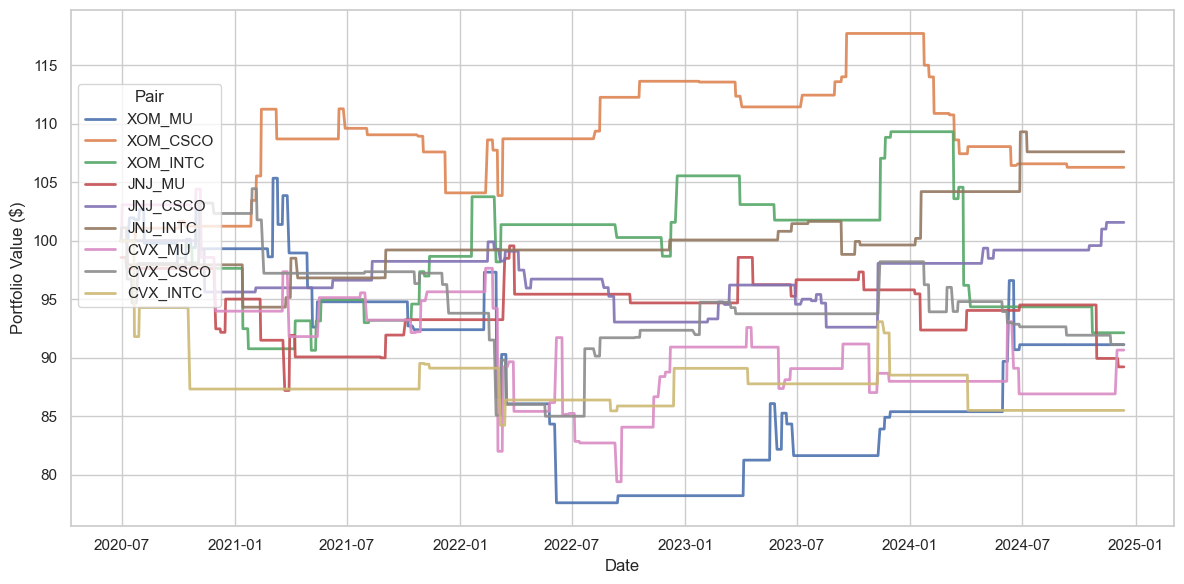

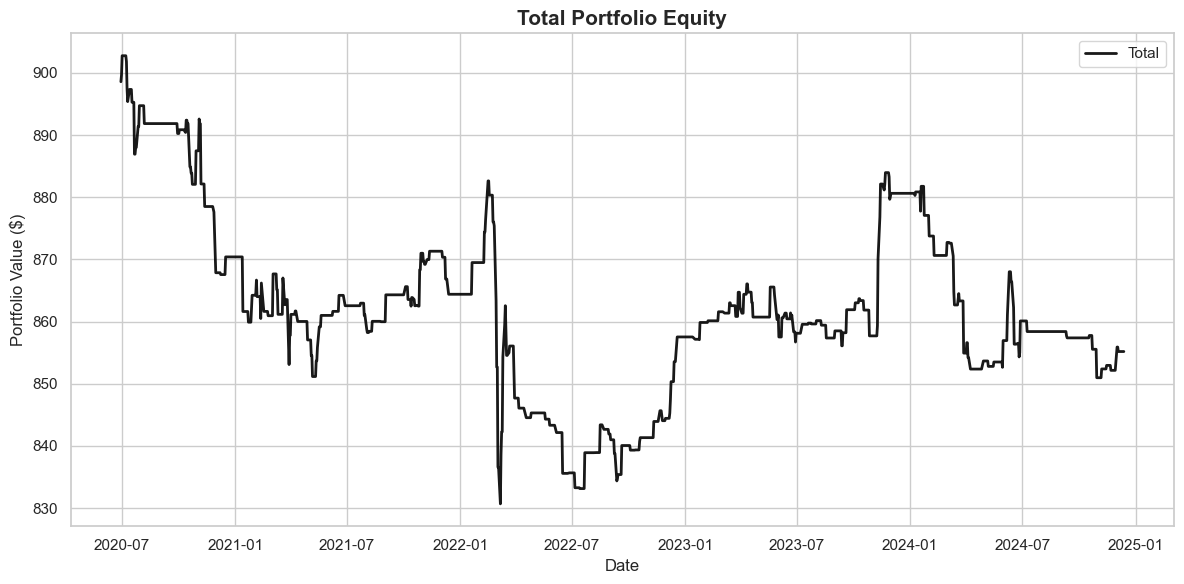

Summary
XOM_MU: Final Value = $91.11, Total Return = -8.89%, Trades = 39
XOM_CSCO: Final Value = $106.28, Total Return = 6.28%, Trades = 37
XOM_INTC: Final Value = $92.13, Total Return = -7.87%, Trades = 31
JNJ_MU: Final Value = $89.22, Total Return = -9.49%, Trades = 28
JNJ_CSCO: Final Value = $101.57, Total Return = 1.57%, Trades = 32
JNJ_INTC: Final Value = $107.60, Total Return = 7.60%, Trades = 18
CVX_MU: Final Value = $90.65, Total Return = -9.35%, Trades = 46
CVX_CSCO: Final Value = $91.13, Total Return = -8.87%, Trades = 42
CVX_INTC: Final Value = $85.50, Total Return = -14.50%, Trades = 16

Total Portfolio Performance
Initial Portfolio Value: $898.57
Final Portfolio Value:   $855.19
Total Return:            -4.83%

Sharpe Ratios
XOM_MU: Sharpe Ratio = -0.11
XOM_CSCO: Sharpe Ratio = 0.26
XOM_INTC: Sharpe Ratio = -0.18
JNJ_MU: Sharpe Ratio = -0.27
JNJ_CSCO: Sharpe Ratio = 0.10
JNJ_INTC: Sharpe Ratio = 0.38
CVX_MU: Sharpe Ratio = -0.11
CVX_CSCO: Sharpe Ratio = -0.21
CVX_INTC: Sha

In [5]:
xgboost.run_simulation(stock_pairs, test_prices, pair_models, feature_cols, pair_betas)